### Mohammed Belal Al-Taharwah
#### freight-rate-prediction task

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### read the Data

In [ ]:
Data = pd.read_csv(
    r"C:\Users\mtahr\OneDrive\Desktop\assignment\freight-rate-prediction\data\train-test.csv"
)

### see first record of data

In [5]:
Data.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


### see the features and datatype and the number of non null value 

In [4]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


### count how many value is null in all features

In [7]:
Data.isnull().sum()

load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

### Update the weight feature to be the median of vehicle weight.

In [ ]:
Data["weight"] = Data.groupby("equipment")["weight"].transform(
    lambda x: x.fillna(x.median())
)

In [ ]:
Data["weight"][0:5]

0    30658.0
1    17555.0
2    31721.0
3    32333.0
4    35183.0
Name: weight, dtype: float64

### manage the nulls value in market index

In [ ]:
Data["market_index"] = Data["market_index"].fillna(Data["market_index"].median())

print("Remaining nulls:", Data.isnull().sum().sum())

Remaining nulls: 0


### convert the date to date type

In [ ]:
Data["date"] = pd.to_datetime(Data["date"])

### Extract date components

In [ ]:
Data["month"] = Data["date"].dt.month
Data["day"] = Data["date"].dt.day
Data["dayofweek"] = Data["date"].dt.dayofweek
Data["is_weekend"] = Data["dayofweek"].isin([5, 6]).astype(int)
Data["dayofyear"] = Data["date"].dt.dayofyear
Data["quarter"] = Data["date"].dt.quarter

### Lane (Origin -> Destination)


In [ ]:
Data["lane"] = Data["pickup"] + " -> " + Data["delivery"]

### Weight density / load ratio

In [ ]:
Data["weight_per_mile"] = Data["weight"] / (Data["distance"] + 1)

### Date Range

In [ ]:
print("Start Date:", Data["date"].min())
print("End Date:", Data["date"].max())

Start Date: 2025-01-01 00:00:00
End Date: 2025-10-31 00:00:00


### know more about the Target

In [ ]:
Data["posted_rate"].describe()

count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64

### The relation between posted rate and distance (Rate per mile)

In [ ]:
Data["rate_per_mile"] = Data["posted_rate"] / Data["distance"]
Data["rate_per_mile"].describe()

count    48000.000000
mean         2.215347
std          0.583887
min          0.333709
25%          1.986974
50%          2.145348
75%          2.342696
max         14.125294
Name: rate_per_mile, dtype: float64

In [ ]:
numeric_cols = Data.select_dtypes(include=[np.number]).columns
Data[numeric_cols].corr()["posted_rate"].sort_values(ascending=False)

posted_rate        1.000000
distance           0.908519
weight             0.034746
market_index       0.034022
dayofyear          0.024492
month              0.023804
quarter            0.017984
day                0.010305
rate_per_mile      0.003147
dayofweek         -0.003383
is_weekend        -0.008299
quote_signal      -0.039858
pickup_lat        -0.090873
delivery_lat      -0.091970
pickup_lon        -0.255058
delivery_lon      -0.257086
weight_per_mile   -0.557677
Name: posted_rate, dtype: float64

In [ ]:
Data.groupby("equipment").agg(
    count=("load_id", "count"),
    mean_rate=("posted_rate", "mean"),
    median_rate_per_mile=("rate_per_mile", "median"),
)

,count,mean_rate,median_rate_per_mile
equipment,,,
Dry Van,27202,2271.548686,2.046203
Flatbed,8753,2445.087223,2.219683
Reefer,12045,2553.636939,2.311540


In [ ]:
print("Unique pickup cities:", Data["pickup"].nunique())
print("Unique delivery cities:", Data["delivery"].nunique())
print("Unique lanes (routes):", Data["lane"].nunique())

Unique pickup cities: 64
Unique delivery cities: 64
Unique lanes (routes): 4014


### split the data to Train and Validation

In [ ]:
split_date = "2025-10-01"
train_df = Data[Data["date"] < split_date].copy()
val_df = Data[Data["date"] >= split_date].copy()  # 1 month for validation
print(f"Train set: {len(train_df):,} rows ({len(train_df) / len(Data) * 100:.1f}%)")
print(f"Validation set: {len(val_df):,} rows ({len(val_df) / len(Data) * 100:.1f}%)")

Train set: 43,147 rows (89.9%)
Validation set: 4,853 rows (10.1%)


In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge

In [ ]:
features = [
    "distance",
    "weight",
    "weight_per_mile",
    "month",
    "day",
    "dayofweek",
    "is_weekend",
    "dayofyear",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "market_index",
    "quote_signal",
]
X_train = train_df[features]
y_train = train_df["posted_rate"]
X_val = val_df[features]
y_val = val_df["posted_rate"]


In [ ]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"=== {model_name} Evaluation ===")
    print(f"RMSE : ${rmse:,.2f}")
    print(f"MAE  : ${mae:,.2f}")
    print(f"R²   : {r2:.4f}")
    return {"model": model_name, "rmse": rmse, "mae": mae, "r2": r2}

In [30]:
baseline = Ridge()
baseline.fit(X_train, y_train)
val_preds_baseline = baseline.predict(X_val)
baseline_metrics = evaluate_model(y_val, val_preds_baseline, "Baseline (Ridge)")

=== Baseline (Ridge) Evaluation ===
RMSE : $666.08
MAE  : $198.32
R²   : 0.8101


In [31]:
import lightgbm as lgb

In [ ]:
lgb_features = [
    "distance",
    "weight",
    "weight_per_mile",
    "equipment",
    "pickup",
    "delivery",
    "month",
    "day",
    "dayofweek",
    "is_weekend",
    "dayofyear",
    "quarter",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "market_index",
    "quote_signal",
]
categorical_cols = ["equipment", "pickup", "delivery"]
# Prepare Train and Validation sets
X_train_lgb = train_df[lgb_features].copy()
X_val_lgb = val_df[lgb_features].copy()

In [ ]:
for col in categorical_cols:
    X_train_lgb[col] = X_train_lgb[col].astype("category")
    X_val_lgb[col] = X_val_lgb[col].astype("category")
# 2. Train LightGBM Model
lgb_model = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42, n_jobs=-1
)
lgb_model.fit(
    X_train_lgb,
    y_train,
    eval_set=[(X_val_lgb, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False)],
)
# 3. Evaluate
val_preds_lgb = lgb_model.predict(X_val_lgb)
lgb_metrics = evaluate_model(y_val, val_preds_lgb, "LightGBM Regressor")

c:\Users\mtahr\OneDrive\Desktop\assignment\freight-rate-prediction\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000669 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1964
[LightGBM] [Info] Number of data points in the train set: 43147, number of used features: 18
[LightGBM] [Info] Start training from score 2373.410351
=== LightGBM Regressor Evaluation ===
RMSE : $657.55
MAE  : $147.39
R²   : 0.8149


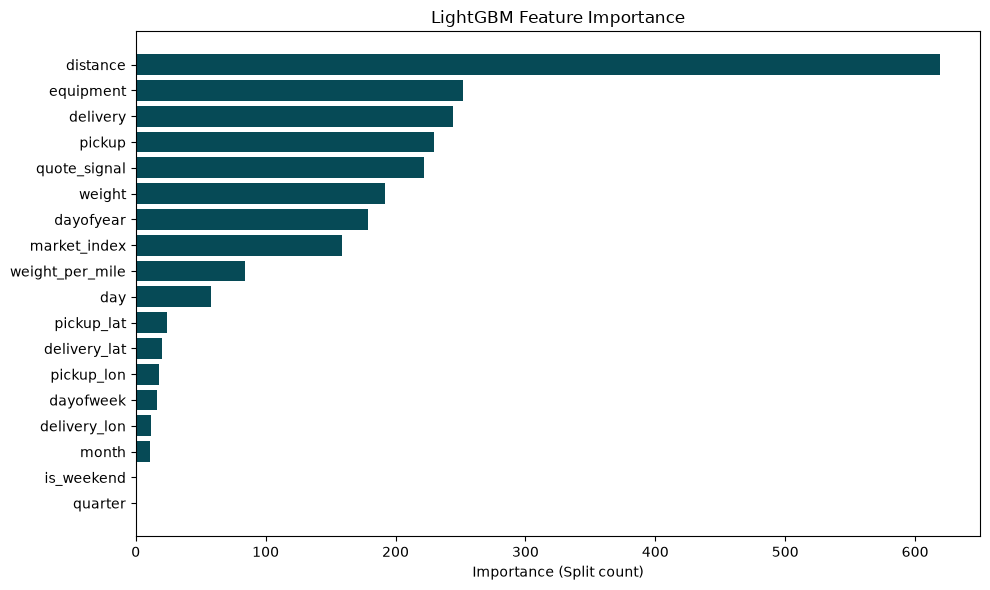

            Feature  Importance
0          distance         619
3         equipment         252
5          delivery         244
4            pickup         230
17     quote_signal         222
1            weight         192
10        dayofyear         179
16     market_index         159
2   weight_per_mile          84
7               day          58
12       pickup_lat          24
14     delivery_lat          20
13       pickup_lon          18
8         dayofweek          16
15     delivery_lon          12
6             month          11
9        is_weekend           0
11          quarter           0


In [ ]:
importance_df = pd.DataFrame(
    {"Feature": lgb_features, "Importance": lgb_model.feature_importances_}
).sort_values("Importance", ascending=False)
plt.figure(figsize=(10, 6))
plt.barh(
    importance_df["Feature"][::-1], importance_df["Importance"][::-1], color="#064A56"
)
plt.title("LightGBM Feature Importance")
plt.xlabel("Importance (Split count)")
plt.tight_layout()
plt.show()
print(importance_df)

In [35]:
# Analyze the largest errors
val_errors = np.abs(y_val - val_preds_lgb)

print("Error Percentiles:")
print("50% (Median Error):", np.percentile(val_errors, 50))
print("75% Error        :", np.percentile(val_errors, 75))
print("90% Error        :", np.percentile(val_errors, 90))
print("99% Error        :", np.percentile(val_errors, 99))
print("Max Error        :", np.max(val_errors))

Error Percentiles:
50% (Median Error): 61.15940742390649
75% Error        : 110.42761655332197
90% Error        : 207.96020021082475
99% Error        : 1737.6107320979704
Max Error        : 13768.921883580324


In [ ]:
# Inspect top 10 worst predictions
worst_cases = val_df.copy()
worst_cases["predicted_rate"] = val_preds_lgb
worst_cases["absolute_error"] = val_errors
worst_cases["error_ratio"] = worst_cases["absolute_error"] / worst_cases["posted_rate"]

worst_cases.sort_values("absolute_error", ascending=False)[
    [
        "pickup",
        "delivery",
        "distance",
        "equipment",
        "weight",
        "rate_per_mile",
        "posted_rate",
        "predicted_rate",
        "absolute_error",
    ]
].head(10)

,pickup,delivery,distance,equipment,weight,rate_per_mile,posted_rate,predicted_rate,absolute_error
43539,Milwaukee,Bakersfield,1893.0,Dry Van,30760.0,9.252039,17514.11,3745.188116,13768.921884
46213,Columbia,Tucson,2023.4,Flatbed,34710.0,8.843120,17893.17,4149.641373,13743.528627
47298,Boston,Bakersfield,2979.1,Reefer,30585.0,6.414790,19110.30,5932.698428,13177.601572
46516,Toledo,Albuquerque,1684.3,Reefer,31536.0,8.777759,14784.38,3600.353115,11184.026885
46366,Bakersfield,Columbia,2251.9,Dry Van,40729.0,6.395994,14403.14,4352.681807,10050.458193
47536,Los Angeles,Richmond,2782.4,Dry Van,25730.0,5.392305,15003.55,4985.803396,10017.746604
44267,Albany,Albuquerque,2492.6,Dry Van,25513.0,5.787298,14425.42,4441.424538,9983.995462
43384,Lexington,Lubbock,1187.0,Dry Van,25359.0,9.853783,11696.44,2477.597712,9218.842288
43302,Atlanta,Phoenix,2083.1,Reefer,40335.0,6.670131,13894.55,4779.615285,9114.934715
47586,Corpus Christi,Las Vegas,1383.3,Flatbed,18645.0,8.383055,11596.28,2892.988101,8703.291899


In [ ]:
worst_cases.sort_values("absolute_error", ascending=False)[
    [
        "date",
        "pickup",
        "delivery",
        "distance",
        "market_index",
        "quote_signal",
        "rate_per_mile",
        "posted_rate",
        "predicted_rate",
    ]
].head(10)

,date,pickup,delivery,distance,market_index,quote_signal,rate_per_mile,posted_rate,predicted_rate
43539,2025-10-03,Milwaukee,Bakersfield,1893.0,1.08079,2.22972,9.252039,17514.11,3745.188116
46213,2025-10-20,Columbia,Tucson,2023.4,0.89822,2.06797,8.843120,17893.17,4149.641373
47298,2025-10-27,Boston,Bakersfield,2979.1,0.86501,2.09472,6.414790,19110.30,5932.698428
46516,2025-10-22,Toledo,Albuquerque,1684.3,0.98632,2.05917,8.777759,14784.38,3600.353115
46366,2025-10-21,Bakersfield,Columbia,2251.9,0.94743,2.19163,6.395994,14403.14,4352.681807
47536,2025-10-29,Los Angeles,Richmond,2782.4,1.03410,2.39203,5.392305,15003.55,4985.803396
44267,2025-10-08,Albany,Albuquerque,2492.6,1.05590,2.38846,5.787298,14425.42,4441.424538
43384,2025-10-02,Lexington,Lubbock,1187.0,0.95849,2.17408,9.853783,11696.44,2477.597712
43302,2025-10-01,Atlanta,Phoenix,2083.1,0.90740,1.94613,6.670131,13894.55,4779.615285
47586,2025-10-29,Corpus Christi,Las Vegas,1383.3,1.01713,2.02448,8.383055,11596.28,2892.988101


Total rows in dataset: 48,000
Normal loads (1.0 <= rate/mile <= 4.0): 47,331 (98.61%)
Outlier loads (rate/mile < 1.0 or > 4.0): 669 (1.39%)


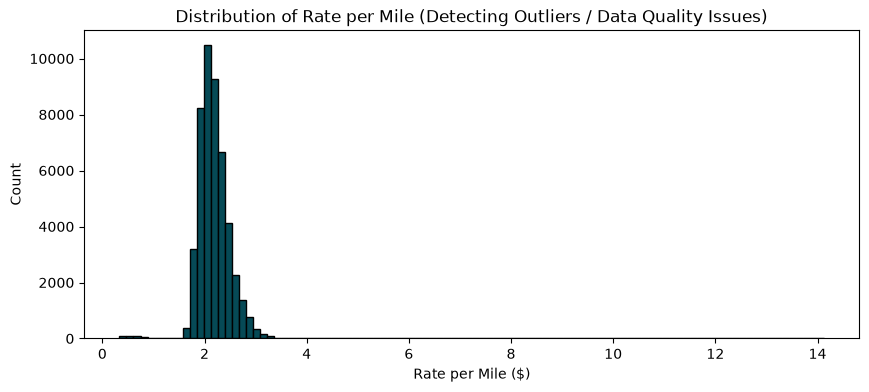

In [ ]:
# Investigate the Data Quality Issue: Extreme Rate per Mile Outliers
normal_loads = Data[(Data["rate_per_mile"] >= 1.0) & (Data["rate_per_mile"] <= 4.0)]
outlier_loads = Data[(Data["rate_per_mile"] < 1.0) | (Data["rate_per_mile"] > 4.0)]

print(f"Total rows in dataset: {len(Data):,}")
print(
    f"Normal loads (1.0 <= rate/mile <= 4.0): {len(normal_loads):,} ({len(normal_loads) / len(Data) * 100:.2f}%)"
)
print(
    f"Outlier loads (rate/mile < 1.0 or > 4.0): {len(outlier_loads):,} ({len(outlier_loads) / len(Data) * 100:.2f}%)"
)

# Visualize the distribution of rate_per_mile
plt.figure(figsize=(10, 4))
plt.hist(Data["rate_per_mile"], bins=100, color="#064A56", edgecolor="black")
plt.title("Distribution of Rate per Mile (Detecting Outliers / Data Quality Issues)")
plt.xlabel("Rate per Mile ($)")
plt.ylabel("Count")
plt.show()

In [ ]:
clean_train_df = train_df[
    (train_df["rate_per_mile"] >= 1.0) & (train_df["rate_per_mile"] <= 4.0)
].copy()

In [ ]:
print(f"Original train size: {len(train_df):,}")
print(
    f"Cleaned train size : {len(clean_train_df):,} (Removed {len(train_df) - len(clean_train_df)} corrupted loads)"
)

Original train size: 43,147
Cleaned train size : 42,557 (Removed 590 corrupted loads)


### re-use LighGBM on clean Data after remove the outliers

In [ ]:
X_train_clean = clean_train_df[lgb_features].copy()
y_train_clean = clean_train_df["posted_rate"]

for col in categorical_cols:
    X_train_clean[col] = X_train_clean[col].astype("category")
clean_lgb_model = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42, n_jobs=-1
)
clean_lgb_model.fit(
    X_train_clean,
    y_train_clean,
    eval_set=[(X_val_lgb, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False)],
)
# 3. Evaluate on Validation Set
val_preds_clean = clean_lgb_model.predict(X_val_lgb)
clean_metrics = evaluate_model(y_val, val_preds_clean, "Clean LightGBM (All Val)")
# 4. Evaluate on Normal Validation Loads (98.6% of market)
normal_val_mask = (val_df["rate_per_mile"] >= 1.0) & (val_df["rate_per_mile"] <= 4.0)
normal_metrics = evaluate_model(
    y_val[normal_val_mask],
    val_preds_clean[normal_val_mask],
    "Clean LightGBM (Normal Val Loads)",
)

c:\Users\mtahr\OneDrive\Desktop\assignment\freight-rate-prediction\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000514 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1963
[LightGBM] [Info] Number of data points in the train set: 42557, number of used features: 18
[LightGBM] [Info] Start training from score 2347.176728
=== Clean LightGBM (All Val) Evaluation ===
RMSE : $646.40
MAE  : $110.93
R²   : 0.8212
=== Clean LightGBM (Normal Val Loads) Evaluation ===
RMSE : $77.11
MAE  : $50.54
R²   : 0.9968


In [ ]:
lex_coords = Data[Data["pickup"] == "Lexington"][["pickup_lat", "pickup_lon"]].iloc[0]
ftw_coords = Data[Data["delivery"] == "Fort Wayne"][
    ["delivery_lat", "delivery_lon"]
].iloc[0]

print("Lexington coords :", lex_coords.to_dict())
print("Fort Wayne coords:", ftw_coords.to_dict())

clean_full_df = Data[
    (Data["rate_per_mile"] >= 1.0) & (Data["rate_per_mile"] <= 4.0)
].copy()

X_full = clean_full_df[lgb_features].copy()
y_full = clean_full_df["posted_rate"]

for col in categorical_cols:
    X_full[col] = X_full[col].astype("category")

final_lgb = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42, n_jobs=-1
)
final_lgb.fit(X_full, y_full)
print("Final Model trained successfully on all clean data!")

Lexington coords : {'pickup_lat': 36.99152, 'pickup_lon': -84.99876}
Fort Wayne coords: {'delivery_lat': 41.31561, 'delivery_lon': -85.36206}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001652 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1962
[LightGBM] [Info] Number of data points in the train set: 47331, number of used features: 18
[LightGBM] [Info] Start training from score 2346.964160
Final Model trained successfully on all clean data!


In [ ]:
val_data = pd.read_csv(
    r"C:\Users\mtahr\OneDrive\Desktop\assignment\freight-rate-prediction\data\validation.csv"
)

val_data["weight"] = val_data.groupby("equipment")["weight"].transform(
    lambda x: x.fillna(clean_full_df.groupby("equipment")["weight"].median()[x.name])
)
val_data["market_index"] = val_data["market_index"].fillna(
    clean_full_df["market_index"].median()
)

val_data["date"] = pd.to_datetime(val_data["date"])
val_data["month"] = val_data["date"].dt.month
val_data["day"] = val_data["date"].dt.day
val_data["dayofweek"] = val_data["date"].dt.dayofweek
val_data["is_weekend"] = val_data["dayofweek"].isin([5, 6]).astype(int)
val_data["dayofyear"] = val_data["date"].dt.dayofyear
val_data["quarter"] = val_data["date"].dt.quarter
val_data["weight_per_mile"] = val_data["weight"] / (val_data["distance"] + 1)

X_val_final = val_data[lgb_features].copy()
for col in categorical_cols:
    X_val_final[col] = X_val_final[col].astype("category")

val_data["predicted_rate"] = np.round(final_lgb.predict(X_val_final), 2)

submission_df = val_data[["load_id", "predicted_rate"]]
submission_df.to_csv(
    r"C:\Users\mtahr\OneDrive\Desktop\assignment\freight-rate-prediction\validation_predictions.csv",
    index=False,
)
print(f"validation_predictions.csv saved successfully! Rows: {len(submission_df):,}")

#  Predict for december-chart-inputs.csv
december_data = pd.read_csv(
    r"C:\Users\mtahr\OneDrive\Desktop\assignment\freight-rate-prediction\data\december-chart-inputs.csv"
)

# Build features for December
december_data["date"] = pd.to_datetime(december_data["date"])
december_data["month"] = december_data["date"].dt.month
december_data["day"] = december_data["date"].dt.day
december_data["dayofweek"] = december_data["date"].dt.dayofweek
december_data["is_weekend"] = december_data["dayofweek"].isin([5, 6]).astype(int)
december_data["dayofyear"] = december_data["date"].dt.dayofyear
december_data["quarter"] = december_data["date"].dt.quarter
december_data["weight_per_mile"] = december_data["weight"] / (
    december_data["distance"] + 1
)

# Coordinates for Lexington & Fort Wayne
december_data["pickup_lat"] = lex_coords["pickup_lat"]
december_data["pickup_lon"] = lex_coords["pickup_lon"]
december_data["delivery_lat"] = ftw_coords["delivery_lat"]
december_data["delivery_lon"] = ftw_coords["delivery_lon"]

# Representative market_index and quote_signal for Dry Van
december_data["market_index"] = clean_full_df["market_index"].median()
december_data["quote_signal"] = clean_full_df[clean_full_df["equipment"] == "Dry Van"][
    "quote_signal"
].median()

X_december = december_data[lgb_features].copy()
for col in categorical_cols:
    X_december[col] = X_december[col].astype("category")

# Predict and round
december_data["predicted_rate"] = np.round(final_lgb.predict(X_december), 2)

# Keep exact 7 required columns
dec_cols = [
    "pickup",
    "delivery",
    "distance",
    "equipment",
    "weight",
    "date",
    "predicted_rate",
]
december_out = december_data[dec_cols].copy()
december_out.to_csv(
    r"C:\Users\mtahr\OneDrive\Desktop\assignment\freight-rate-prediction\data\december_predictions.csv",
    index=False,
)
print(f"data/december_predictions.csv saved successfully! Rows: {len(december_out)}")

validation_predictions.csv saved successfully! Rows: 12,000
data/december_predictions.csv saved successfully! Rows: 31
